Tải dataset

In [ ]:
import os
import shutil
from datasets import load_dataset
from tqdm import tqdm
from PIL import Image
import warnings
from google.colab import drive

# Bỏ qua cảnh báo
warnings.filterwarnings("ignore", category=UserWarning, module='PIL')

# ================= CẤU HÌNH =================
FINAL_DIR = "./trashnet-dataset-final"
KAGGLE_DIR = "./kaggle_raw_data"

# Nguồn dữ liệu
KAGGLE_MAIN = "sumn2u/garbage-classification-v2"

# Cấu hình file zip trên Drive (Sửa tên file nếu cần)
# Giả sử file của bạn tên là 'plastic_bag.zip' nằm ở thư mục gốc Drive
DRIVE_BAG_ZIP = "/content/drive/MyDrive/plastic_bag.rar" # Hoặc .zip tùy file bạn up
# Nếu là file .rar, bạn cần cài unrar (xem phần code dưới)

# Cấu hình số lượng
LIMITS = {
    "bio": 1300,
    "battery": 999999,
    "plastic_bag": 1500 # Giới hạn cho túi nilon từ Drive (nếu cần)
}
# ============================================

# 1. Dọn dẹp & Cài đặt
print("🧹 Đang dọn dẹp và chuẩn bị...")
if os.path.exists(FINAL_DIR): shutil.rmtree(FINAL_DIR, ignore_errors=True)
if os.path.exists(KAGGLE_DIR): shutil.rmtree(KAGGLE_DIR, ignore_errors=True)

# Cài thư viện (Thêm pyunpack patool nếu file là .rar)
os.system("pip install -q kaggle transformers datasets accelerate torch scikit-learn patool pyunpack")
# Cài unrar cho hệ thống linux (để giải nén .rar)
os.system("apt-get install unrar")

# Kích hoạt Kaggle
if os.path.exists("kaggle.json"):
    os.system("mkdir -p ~/.kaggle")
    os.system("cp kaggle.json ~/.kaggle/")
    os.system("chmod 600 ~/.kaggle/kaggle.json")
else:
    print("⚠️ Lưu ý: Không thấy file kaggle.json (Có thể ảnh hưởng đến việc lấy Pin).")

# 2. Kết nối Drive
print("🔌 Đang kết nối Google Drive...")
drive.mount('/content/drive')

# 3. Tải nguồn dữ liệu Online
print("📦 [1/3] Tải TrashNet gốc (HF)...")
ds_orig = load_dataset("garythung/trashnet", split="train")

print("🌿 [2/3] Tải Bio bổ sung (HF)...")
ds_bio_hf = load_dataset("rootstrap-org/waste-classifier", split="train")

print(f"📥 [3/3] Tải Kaggle Main (Lấy Pin)...")
if os.path.exists("kaggle.json"):
    os.system(f"kaggle datasets download -d {KAGGLE_MAIN} --path {KAGGLE_DIR} --unzip")

# Hàm kiểm tra số lượng
def get_current_count(label):
    path = f"{FINAL_DIR}/train/{label}"
    if not os.path.exists(path): return 0
    return len(os.listdir(path))

# --- HÀM LƯU TỪ HUGGING FACE ---
def save_hf_images(dataset, source_name):
    labels = dataset.features['label'].names
    for i, item in enumerate(tqdm(dataset, desc=f"Xử lý HF {source_name}", position=0, leave=True)):
        label_name = labels[item['label']]
        if label_name == "compost": label_name = "bio"
        if label_name == "trash": continue

        if label_name in ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'bio']:
            limit = LIMITS.get(label_name, 999999)
            if get_current_count(label_name) >= limit: continue

            save_path = f"{FINAL_DIR}/train/{label_name}"
            os.makedirs(save_path, exist_ok=True)
            try:
                if item['image'].mode != "RGB": item['image'] = item['image'].convert("RGB")
                item['image'].save(f"{save_path}/{source_name}_{i}.jpg")
            except: pass

# --- HÀM LƯU TỪ KAGGLE (MAIN) ---
def save_kaggle_main(source_dir):
    if not os.path.exists(source_dir): return
    print("🔍 Đang quét Kaggle Main...")
    all_files = []
    for root, _, files in os.walk(source_dir):
        folder_name = os.path.basename(root).lower()
        target_label = None
        if folder_name == "biological": target_label = "bio"
        elif folder_name == "battery":  target_label = "battery"

        if target_label:
            for f in files:
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_files.append((target_label, os.path.join(root, f), f))

    for target_label, src_path, filename in tqdm(all_files, desc="Xử lý Kaggle Main", position=0, leave=True):
        limit = LIMITS.get(target_label, 999999)
        if get_current_count(target_label) >= limit: continue
        save_path = f"{FINAL_DIR}/train/{target_label}"
        os.makedirs(save_path, exist_ok=True)
        try:
            img = Image.open(src_path)
            if img.mode != "RGB": img = img.convert("RGB")
            img.save(f"{save_path}/kaggle_{filename}")
        except: pass

# --- HÀM LẤY TÚI NILON TỪ DRIVE ---
def extract_plastic_bag_from_drive():
    print(f"🛍️ Đang xử lý Plastic Bag từ Drive: {DRIVE_BAG_ZIP} ...")

    if not os.path.exists(DRIVE_BAG_ZIP):
        print(f"❌ LỖI: Không tìm thấy file '{DRIVE_BAG_ZIP}' trên Drive.")
        return

    # Tạo thư mục tạm để giải nén
    temp_extract_dir = "./temp_bag_extract"
    if os.path.exists(temp_extract_dir): shutil.rmtree(temp_extract_dir)
    os.makedirs(temp_extract_dir, exist_ok=True)

    # Giải nén (Hỗ trợ cả .zip và .rar)
    try:
        if DRIVE_BAG_ZIP.endswith(".zip"):
            shutil.unpack_archive(DRIVE_BAG_ZIP, temp_extract_dir)
        elif DRIVE_BAG_ZIP.endswith(".rar"):
            # Dùng unrar cho file rar
            os.system(f"unrar x \"{DRIVE_BAG_ZIP}\" \"{temp_extract_dir}\" > /dev/null")

        print("✅ Giải nén thành công. Đang lọc và chép ảnh...")

        # Đích đến
        target_label = "plastic_bag"
        save_path = f"{FINAL_DIR}/train/{target_label}"
        os.makedirs(save_path, exist_ok=True)

        count = 0
        limit = LIMITS.get(target_label, 999999)

        # Duyệt và copy ảnh
        for root, _, files in os.walk(temp_extract_dir):
            for file in tqdm(files, desc="Chép ảnh túi nilon"):
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    if get_current_count(target_label) >= limit: break

                    try:
                        src = os.path.join(root, file)
                        # Chuẩn hóa ảnh (nếu cần)
                        img = Image.open(src)
                        if img.mode != "RGB": img = img.convert("RGB")

                        dst = f"{save_path}/drive_{count}_{file}"
                        img.save(dst)
                        count += 1
                    except: pass

        # Dọn dẹp thư mục tạm
        shutil.rmtree(temp_extract_dir)

    except Exception as e:
        print(f"❌ Lỗi khi giải nén: {e}")

# --- THỰC THI ---
save_hf_images(ds_orig, "hf_orig")
save_hf_images(ds_bio_hf, "hf_bio")
save_kaggle_main(KAGGLE_DIR)
extract_plastic_bag_from_drive() # <--- Lấy túi nilon từ Drive

# --- BÁO CÁO ---
print("\n" + "="*40)
print("📊 KẾT QUẢ CUỐI CÙNG (8 CLASSES)")
if os.path.exists(f"{FINAL_DIR}/train"):
    labels = sorted(os.listdir(f"{FINAL_DIR}/train"))
    for label in labels:
        path = f"{FINAL_DIR}/train/{label}"
        count = len(os.listdir(path))
        print(f"   - {label.upper():<12}: {count:<5} ảnh")
print("-" * 40)
print(f"   - TỔNG CỘNG : {len(labels)} Lớp")
print("="*40)

🧹 Đang dọn dẹp và chuẩn bị...
🔌 Đang kết nối Google Drive...
Mounted at /content/drive
📦 [1/3] Tải TrashNet gốc (HF)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

dataset-original.zip:   0%|          | 0.00/3.63G [00:00<?, ?B/s]

dataset-resized.zip:   0%|          | 0.00/42.8M [00:00<?, ?B/s]

...

🔍 Đang quét Kaggle Main...


Xử lý Kaggle Main: 100%|██████████| 1941/1941 [00:03<00:00, 642.88it/s]


🛍️ Đang xử lý Plastic Bag từ Drive: /content/drive/MyDrive/plastic_bag.rar ...
✅ Giải nén thành công. Đang lọc và chép ảnh...


Chép ảnh túi nilon: 0it [00:00, ?it/s]
Chép ảnh túi nilon: 100%|██████████| 1500/1500 [00:10<00:00, 137.00it/s]



📊 KẾT QUẢ CUỐI CÙNG (8 CLASSES)
   - BATTERY     : 944   ảnh
   - BIO         : 1300  ảnh
   - CARDBOARD   : 1239  ảnh
   - GLASS       : 1136  ảnh
   - METAL       : 1135  ảnh
   - PAPER       : 1752  ảnh
   - PLASTIC     : 1272  ảnh
   - PLASTIC_BAG : 1500  ảnh
----------------------------------------
   - TỔNG CỘNG : 8 Lớp


Tải Models AI

In [ ]:
!pip install -U transformers

Train AI

In [ ]:
from transformers import AutoModelForImageClassification, AutoImageProcessor, TrainingArguments, Trainer
from datasets import load_dataset
import torch
import numpy as np
from sklearn.metrics import accuracy_score
import os

# ================= CẤU HÌNH TÊN CHUNG =================
DATA_DIR = "./trashnet-dataset-final"  # <--- Khớp với code 1
OUTPUT_DIR = "./trashnet-model-final"  # <--- Tên model chung
MODEL_NAME = "google/siglip-base-patch16-224"
# ======================================================

print(f"🚀 Đang kiểm tra dữ liệu tại: {DATA_DIR} ...")
if not os.path.exists(DATA_DIR):
    print(f"❌ LỖI: Không tìm thấy thư mục '{DATA_DIR}'.")
    exit()

# Tải dataset
print("⏳ Đang nạp dữ liệu...")
dataset = load_dataset("imagefolder", data_dir=DATA_DIR)
dataset = dataset['train'].train_test_split(test_size=0.1)

labels = dataset['train'].features['label'].names
num_labels = len(labels)
print(f"✅ Đã tìm thấy {num_labels} Lớp: {labels}")

label2id = {label: str(i) for i, label in enumerate(labels)}
id2label = {str(i): label for i, label in enumerate(labels)}

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True
)

def transform(batch):
    inputs = processor([x for x in batch['image']], return_tensors='pt')
    inputs['labels'] = batch['label']
    return inputs

prepared_ds = dataset.with_transform(transform)

args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=16,
    learning_rate=5e-5,
    num_train_epochs=3,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True,
    remove_unused_columns=False,
    report_to="none"
)

def compute_metrics(p):
    return {"accuracy": accuracy_score(p.label_ids, np.argmax(p.predictions, axis=1))}

trainer = Trainer(
    model=model, args=args,
    train_dataset=prepared_ds["train"],
    eval_dataset=prepared_ds["test"],
    tokenizer=processor,
    compute_metrics=compute_metrics
)

print("\n🔥 BẮT ĐẦU HUẤN LUYỆN...")
trainer.train()
print("\n🎉 HUẤN LUYỆN THÀNH CÔNG!")

🚀 Đang kiểm tra dữ liệu tại: ./trashnet-dataset-final ...
⏳ Đang nạp dữ liệu...


Resolving data files:   0%|          | 0/10278 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

✅ Đã tìm thấy 8 Lớp: ['battery', 'bio', 'cardboard', 'glass', 'metal', 'paper', 'plastic', 'plastic_bag']


preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Some weights of SiglipForImageClassification were not initialized from the model checkpoint at google/siglip-base-patch16-224 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3782147931.py:58: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



🔥 BẮT ĐẦU HUẤN LUYỆN...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.341300,0.286329,0.927043
2,0.116100,0.068686,0.982490
3,0.024400,0.060231,0.982490



🎉 HUẤN LUYỆN THÀNH CÔNG!


Thống kê

📊 [1/3] ĐANG PHÂN TÍCH DỮ LIỆU...

📋 BẢNG THỐNG KÊ CHI TIẾT
LOẠI RÁC        | SỐ LƯỢNG   | TỶ LỆ (%)
---------------------------------------------
BATTERY         | 944        | 9.2%
BIO             | 1300       | 12.6%
CARDBOARD       | 1239       | 12.1%
GLASS           | 1136       | 11.1%
METAL           | 1135       | 11.0%
PAPER           | 1752       | 17.0%
PLASTIC         | 1272       | 12.4%
PLASTIC_BAG     | 1500       | 14.6%
---------------------------------------------
TỔNG CỘNG       | 10278      | 100%


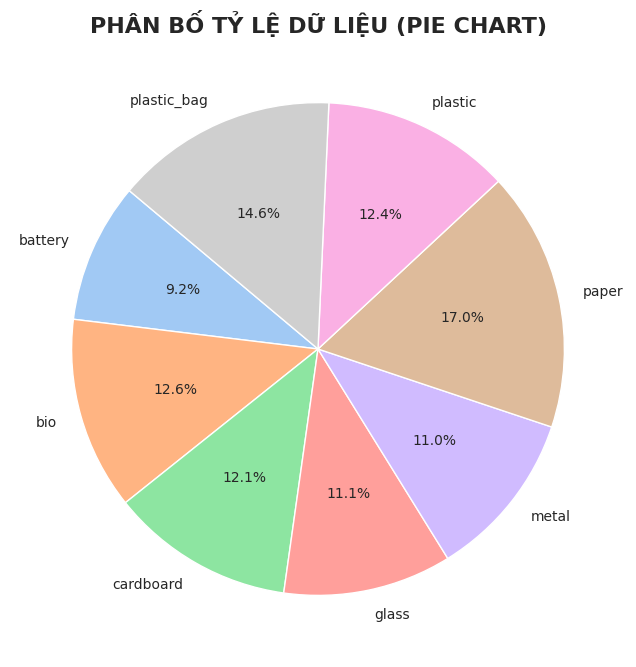

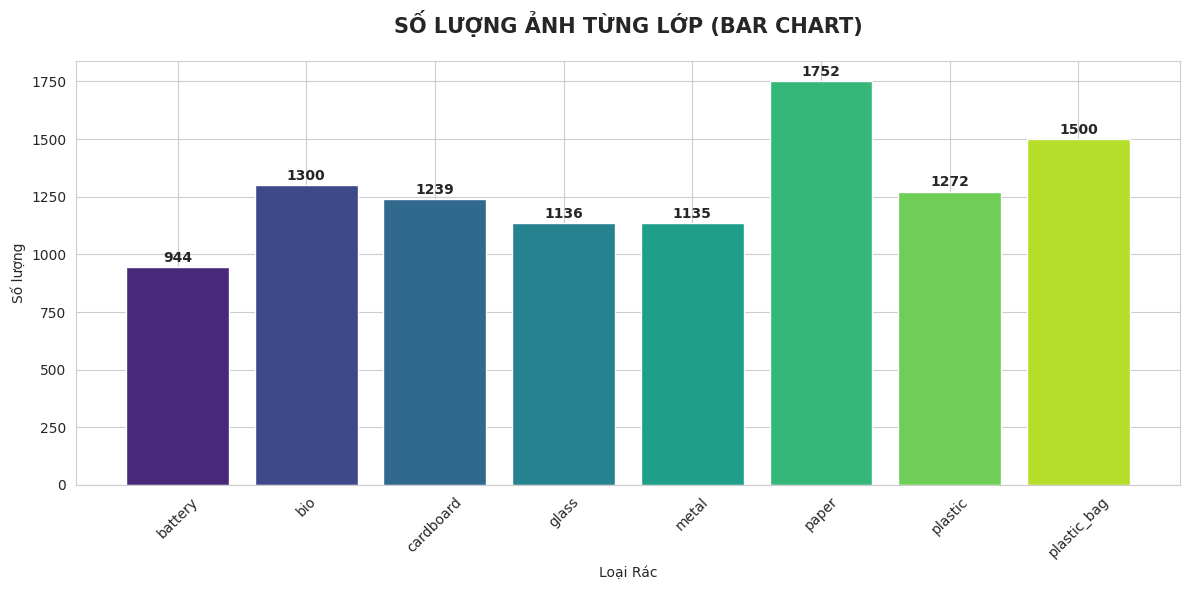


🚀 [2/3] ĐANG CHẠY TEST THEO CÁC MỐC TỪ 10% -> 100%...


   👉 Data: 10 % (102  ảnh) | Accuracy: 99.02%


   👉 Data: 20 % (205  ảnh) | Accuracy: 98.54%


   👉 Data: 30 % (308  ảnh) | Accuracy: 98.70%


   👉 Data: 40 % (411  ảnh) | Accuracy: 98.78%


...

   👉 Data: 60 % (616  ảnh) | Accuracy: 98.38%


   👉 Data: 70 % (719  ảnh) | Accuracy: 98.47%


   👉 Data: 80 % (822  ảnh) | Accuracy: 98.42%


   👉 Data: 90 % (925  ảnh) | Accuracy: 98.38%


   👉 Data: 100% (1028 ảnh) | Accuracy: 98.25%


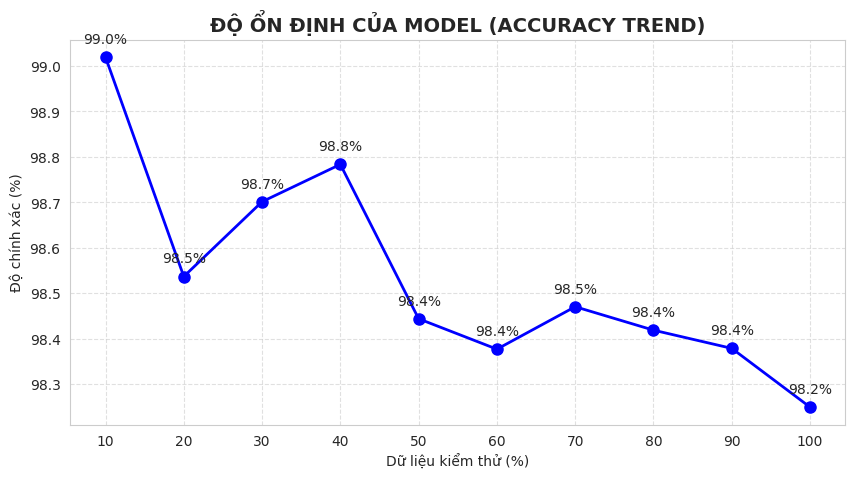


🏆 [3/3] BÁO CÁO KẾT QUẢ CUỐI CÙNG...


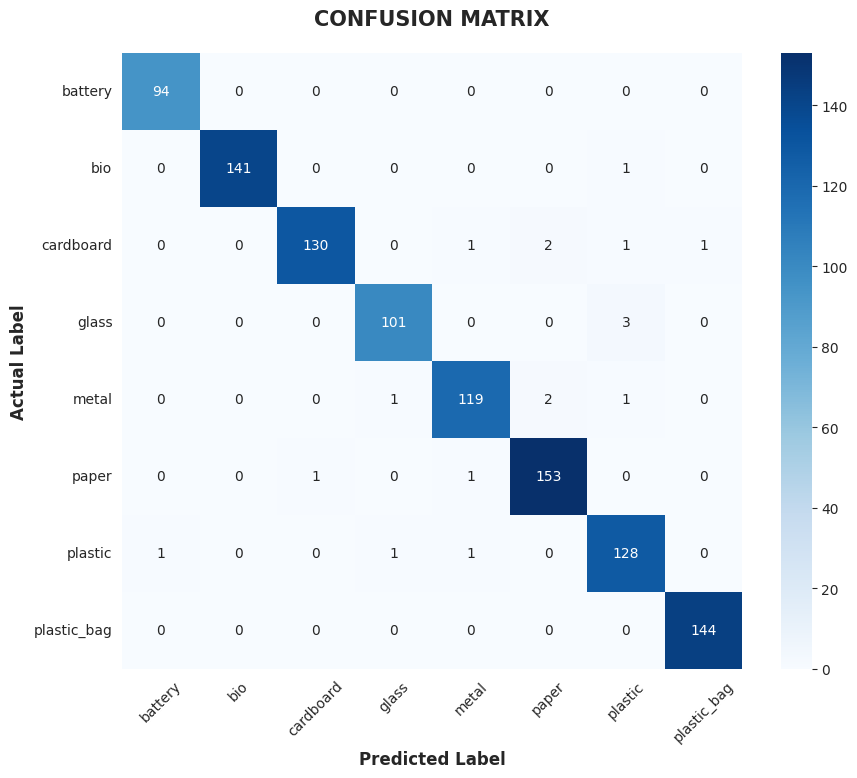

/tmp/ipython-input-2191631469.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette="viridis")


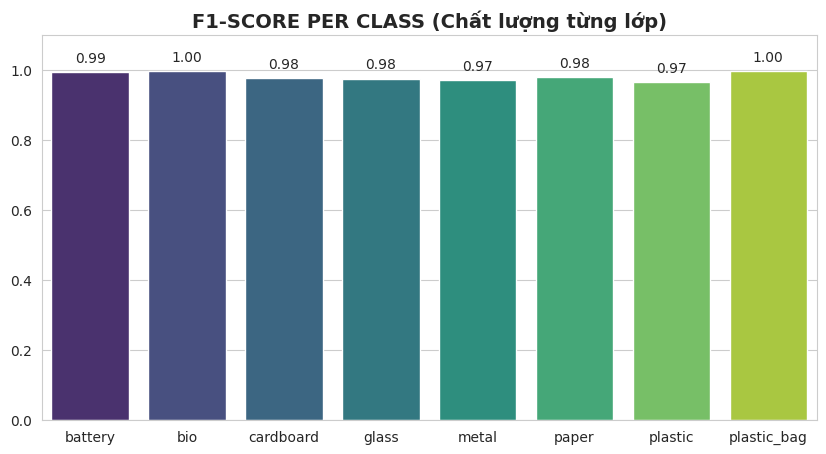


📋 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     battery       0.99      1.00      0.99        94
         bio       1.00      0.99      1.00       142
   cardboard       0.99      0.96      0.98       135
       glass       0.98      0.97      0.98       104
       metal       0.98      0.97      0.97       123
       paper       0.97      0.99      0.98       155
     plastic       0.96      0.98      0.97       131
 plastic_bag       0.99      1.00      1.00       144

    accuracy                           0.98      1028
   macro avg       0.98      0.98      0.98      1028
weighted avg       0.98      0.98      0.98      1028



In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Cài đặt giao diện
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ================= PHẦN 1: THỐNG KÊ DỮ LIỆU ĐẦU VÀO =================
print("📊 [1/3] ĐANG PHÂN TÍCH DỮ LIỆU...")

DATA_DIR = "./trashnet-dataset-final/train"

if os.path.exists(DATA_DIR):
    classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])

    counts = []
    total_images = 0
    temp_counts = {}

    for label in classes:
        path = os.path.join(DATA_DIR, label)
        num = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        temp_counts[label] = num
        counts.append(num)
        total_images += num

    # --- 1.1 IN BẢNG SỐ LIỆU ---
    print("\n" + "="*45)
    print("📋 BẢNG THỐNG KÊ CHI TIẾT")
    print("="*45)
    print(f"{'LOẠI RÁC':<15} | {'SỐ LƯỢNG':<10} | {'TỶ LỆ (%)'}")
    print("-" * 45)
    for label in classes:
        num = temp_counts[label]
        percent = (num / total_images) * 100 if total_images > 0 else 0
        print(f"{label.upper():<15} | {num:<10} | {percent:.1f}%")
    print("-" * 45)
    print(f"{'TỔNG CỘNG':<15} | {total_images:<10} | 100%")
    print("="*45)

    # --- 1.2 BIỂU ĐỒ TRÒN (PIE CHART) - Đã khôi phục ---
    plt.figure(figsize=(8, 8))
    plt.pie(counts, labels=classes, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
    plt.title('PHÂN BỐ TỶ LỆ DỮ LIỆU (PIE CHART)', fontsize=16, fontweight='bold')
    plt.show()

    # --- 1.3 BIỂU ĐỒ CỘT (BAR CHART) - Giữ nguyên ---
    plt.figure(figsize=(12, 6))
    palette = sns.color_palette("viridis", len(classes))
    bars = plt.bar(classes, counts, color=palette)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval),
                 ha='center', va='bottom', fontweight='bold', fontsize=10)
    plt.title(f'SỐ LƯỢNG ẢNH TỪNG LỚP (BAR CHART)', fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Loại Rác')
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print(f"❌ Lỗi: Không tìm thấy thư mục '{DATA_DIR}'")

# ================= PHẦN 2: KIỂM THỬ TĂNG DẦN (10% -> 100%) =================
if 'trainer' in locals() and 'prepared_ds' in locals():
    print("\n🚀 [2/3] ĐANG CHẠY TEST THEO CÁC MỐC TỪ 10% -> 100%...")

    full_test_dataset = prepared_ds["test"]
    total_samples = len(full_test_dataset)
    percents = []
    accuracies = []

    for p in range(10, 101, 10):
        num_samples = int(total_samples * (p / 100))
        subset = full_test_dataset.select(range(num_samples))

        predictions = trainer.predict(subset)
        y_pred = np.argmax(predictions.predictions, axis=1)
        y_true = predictions.label_ids

        acc = accuracy_score(y_true, y_pred)
        percents.append(p)
        accuracies.append(acc * 100)
        print(f"   👉 Data: {p:<3}% ({num_samples:<4} ảnh) | Accuracy: {acc*100:.2f}%")

    # --- 2.1 BIỂU ĐỒ ĐƯỜNG (LINE CHART) ---
    plt.figure(figsize=(10, 5))
    plt.plot(percents, accuracies, marker='o', linestyle='-', color='blue', linewidth=2, markersize=8)
    plt.title('ĐỘ ỔN ĐỊNH CỦA MODEL (ACCURACY TREND)', fontsize=14, fontweight='bold')
    plt.xlabel('Dữ liệu kiểm thử (%)')
    plt.ylabel('Độ chính xác (%)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(np.arange(10, 101, 10))
    for i, txt in enumerate(accuracies):
        plt.annotate(f"{txt:.1f}%", (percents[i], accuracies[i]), textcoords="offset points", xytext=(0,10), ha='center')
    plt.show()

# ================= PHẦN 3: BÁO CÁO CUỐI CÙNG =================
    print("\n🏆 [3/3] BÁO CÁO KẾT QUẢ CUỐI CÙNG...")
    class_names = [id2label[str(i)] for i in range(len(id2label))]

    # --- 3.1 CONFUSION MATRIX ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
    plt.title('CONFUSION MATRIX', fontsize=15, fontweight='bold', pad=20)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

    # --- 3.2 F1-SCORE PER CLASS ---
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    f1_scores = {k: v['f1-score'] for k, v in report_dict.items() if k in class_names}

    plt.figure(figsize=(10, 5))
    bar_plot = sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette="viridis")
    plt.title('F1-SCORE PER CLASS (Chất lượng từng lớp)', fontsize=14, fontweight='bold')
    plt.ylim(0, 1.1)
    for p in bar_plot.patches:
        bar_plot.annotate(f'{p.get_height():.2f}',
                          (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha = 'center', va = 'center',
                          xytext = (0, 10), textcoords = 'offset points')
    plt.show()

    print("\n📋 DETAILED CLASSIFICATION REPORT:")
    print(classification_report(y_true, y_pred, target_names=class_names))

else:
    print("\n⚠️ CẢNH BÁO: Không tìm thấy Model! Vui lòng chạy lệnh 'trainer.train()' trước.")

Lưu Model và Dataset về máy

In [ ]:
from google.colab import files
import os
import shutil

# ================= CẤU HÌNH =================
# Tên file zip bạn muốn tải về
ZIP_NAME = "trashnet-advanced-full.zip"

# Tên các thư mục cần đóng gói (Phải khớp với các bước trên)
MODEL_DIR = "./trashnet-model-final"
DATASET_DIR = "./trashnet-dataset-final"
# ============================================

print("💾 1. Đang lưu cấu hình Model...")
if 'trainer' in locals():
    trainer.save_model(MODEL_DIR)
    processor.save_pretrained(MODEL_DIR)
else:
    print("⚠️ Cảnh báo: Không tìm thấy biến 'trainer', hy vọng bạn đã save model trước đó.")

print(f"📦 2. Đang nén toàn bộ (Model + Dataset) thành file '{ZIP_NAME}'...")
print("   (Quá trình này có thể mất vài phút vì dataset khá nặng, vui lòng đợi...)")

# Lệnh nén cả 2 thư mục vào 1 file zip
# Cấu trúc lệnh: zip -r [TênFile] [ThưMục1] [ThưMục2]
exit_code = os.system(f"zip -r -q {ZIP_NAME} {MODEL_DIR} {DATASET_DIR}")

if exit_code == 0:
    print(f"✅ Đã nén xong! File nặng khoảng vài trăm MB.")
    print(f"⬇️ 3. Đang gửi lệnh tải '{ZIP_NAME}' về máy tính...")

    try:
        files.download(ZIP_NAME)
    except Exception as e:
        print("⚠️ Trình duyệt chặn tải tự động.")
        print("👉 Hãy nhìn sang cột bên trái (biểu tượng Thư mục).")
        print(f"👉 Tìm file '{ZIP_NAME}', chuột phải -> Download.")
else:
    print("❌ Lỗi khi nén file. Vui lòng kiểm tra lại tên thư mục.")

💾 1. Đang lưu cấu hình Model...
📦 2. Đang nén toàn bộ (Model + Dataset) thành file 'trashnet-advanced-full.zip'...
   (Quá trình này có thể mất vài phút vì dataset khá nặng, vui lòng đợi...)
✅ Đã nén xong! File nặng khoảng vài trăm MB.
⬇️ 3. Đang gửi lệnh tải 'trashnet-advanced-full.zip' về máy tính...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>